# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

df = pd.read_csv('../data/cleaned_churn.csv')

# Color palette
CHURN_COLORS = ['#2ecc71', '#e74c3c']  # Green=No, Red=Yes
sns.set_style('whitegrid')
sns.set_palette(CHURN_COLORS)

print("Shape:", df.shape)
print(df['Churn'].value_counts())

Shape: (7032, 21)
Churn
0    5163
1    1869
Name: count, dtype: int64


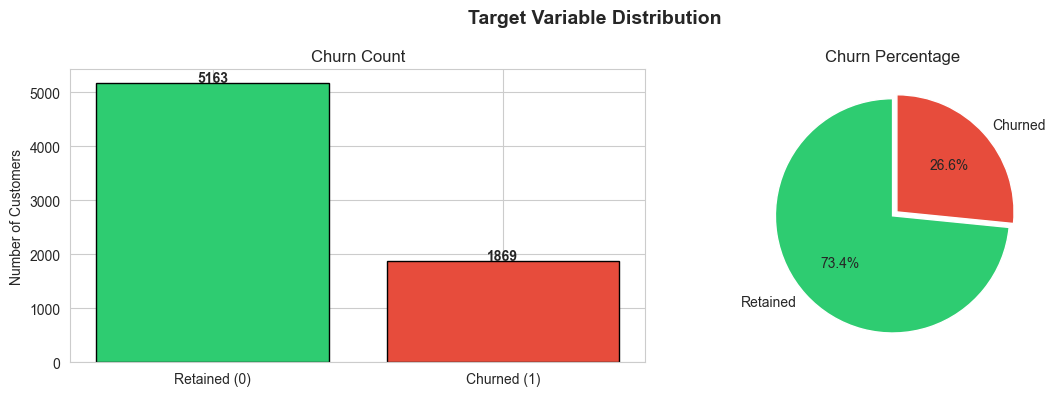

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['Churn'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], counts.values, color=CHURN_COLORS, edgecolor='black')
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Retained', 'Churned'],
            colors=CHURN_COLORS, autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Percentage')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/01_churn_distribution.png', dpi=150)
plt.show()

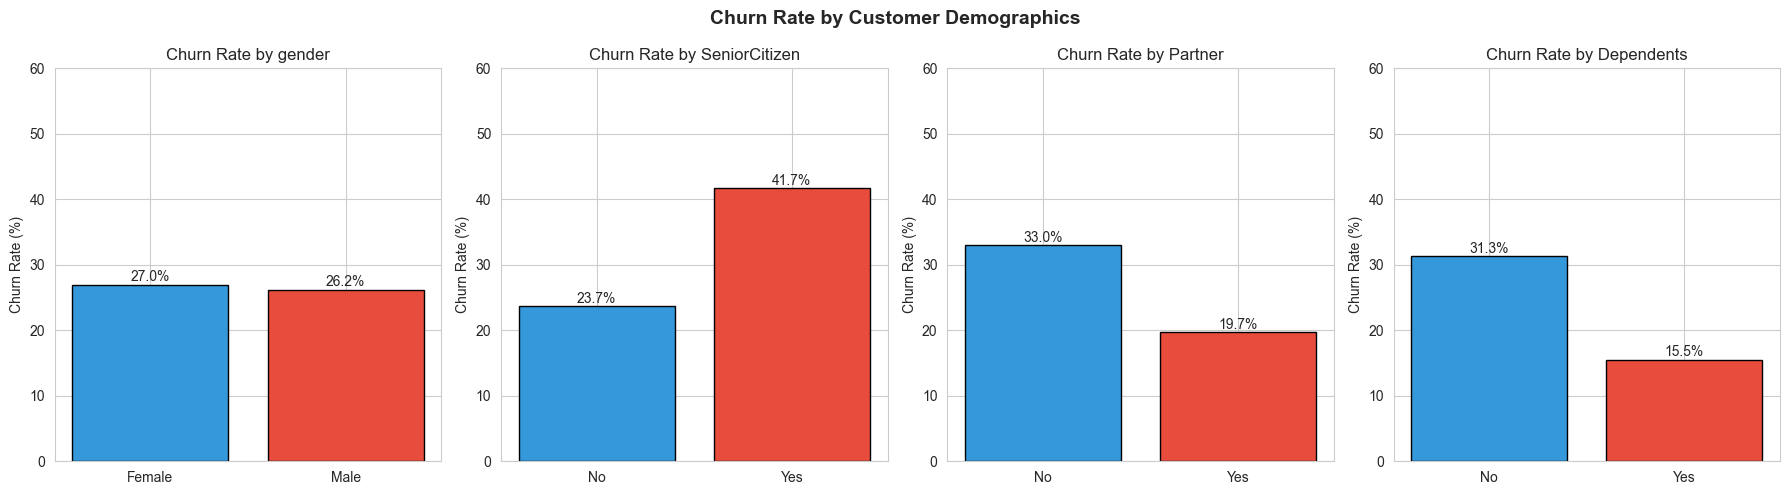

In [4]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(demo_cols):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=['#3498db', '#e74c3c'], edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 60)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Churn Rate by Customer Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_churn_by_demographics.png', dpi=150)
plt.show()

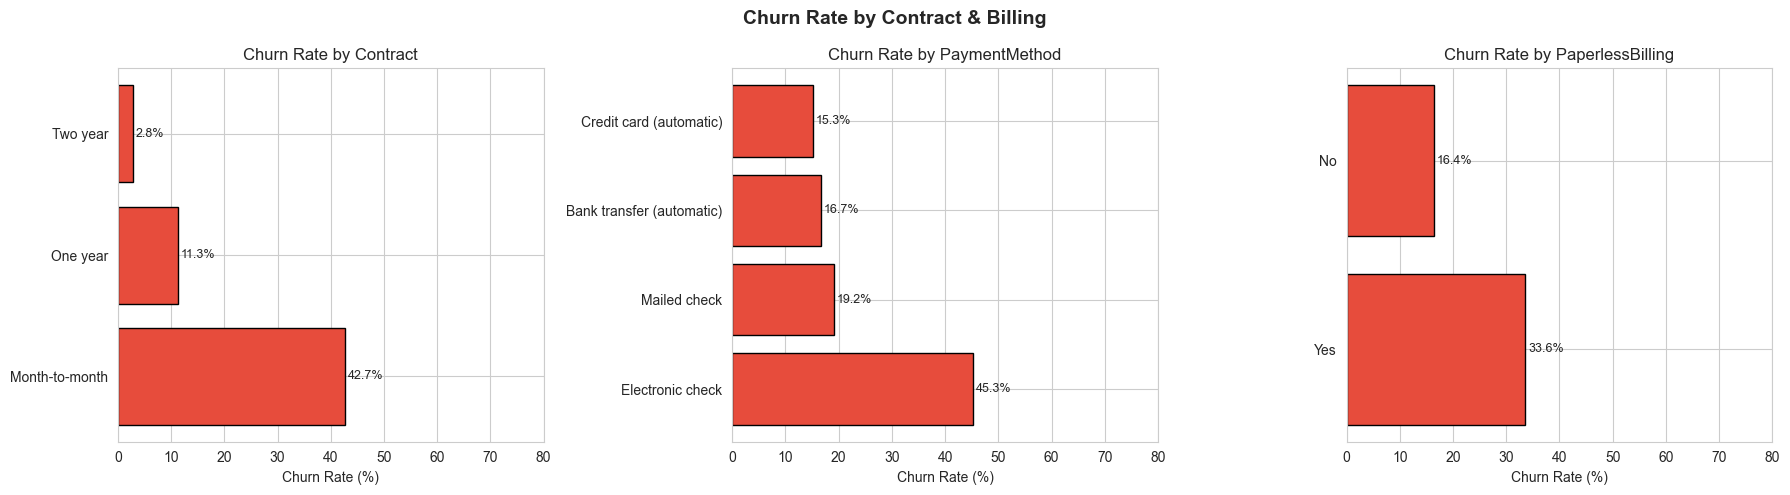

In [5]:
contract_cols = ['Contract', 'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(contract_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = axes[i].barh(churn_rate.index, churn_rate.values,
                        color='#e74c3c', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel('Churn Rate (%)')
    axes[i].set_xlim(0, 80)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Churn Rate by Contract & Billing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_churn_by_contract.png', dpi=150)
plt.show()

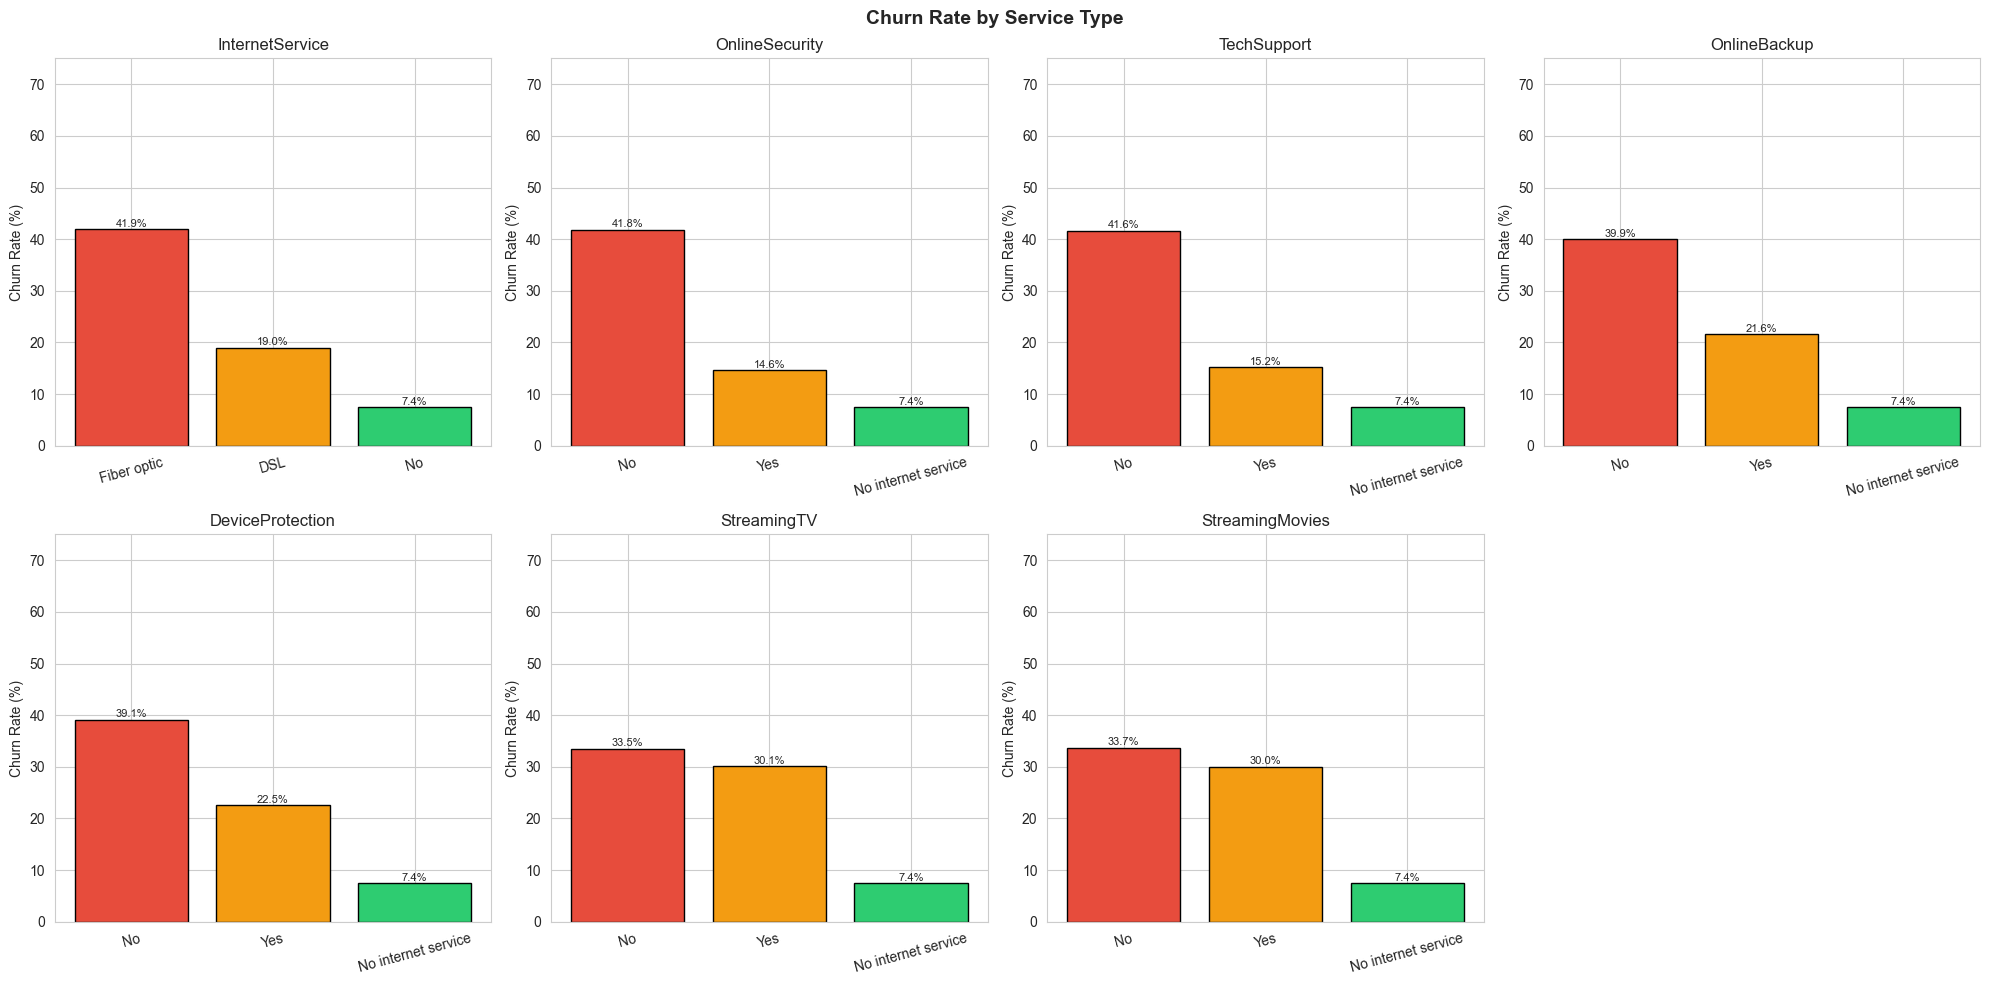

In [6]:
service_cols = ['InternetService', 'OnlineSecurity', 'TechSupport',
                'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies']

churn_rates = {col: df.groupby(col)['Churn'].mean() * 100 for col in service_cols}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    rate = churn_rates[col].sort_values(ascending=False)
    bars = axes[i].bar(rate.index, rate.values,
                       color=['#e74c3c', '#f39c12', '#2ecc71'][:len(rate)],
                       edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 75)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Churn Rate by Service Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/04_churn_by_services.png', dpi=150)
plt.show()

C:\Users\Dw\AppData\Local\Temp\ipykernel_18004\3218410840.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['Churn']==0]['tenure'], df[df['Churn']==1]['tenure']],


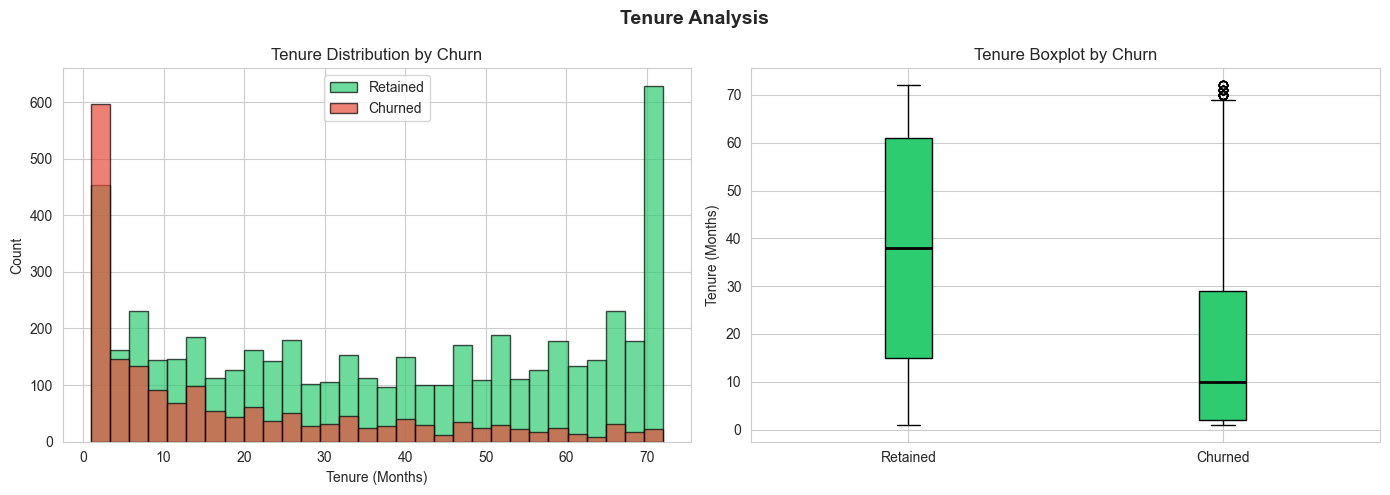

Avg tenure — Retained: 37.7
Avg tenure — Churned : 18.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for churn_val, label, color in zip([0, 1], ['Retained', 'Churned'], CHURN_COLORS):
    subset = df[df['Churn'] == churn_val]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.7, label=label, color=color, edgecolor='black')
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
df_plot = df.copy()
df_plot['Churn_Label'] = df_plot['Churn'].map({0: 'Retained', 1: 'Churned'})
axes[1].boxplot([df[df['Churn']==0]['tenure'], df[df['Churn']==1]['tenure']],
                labels=['Retained', 'Churned'],
                patch_artist=True,
                boxprops=dict(facecolor='#2ecc71'),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Tenure Boxplot by Churn')
axes[1].set_ylabel('Tenure (Months)')

plt.suptitle('Tenure Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_tenure_analysis.png', dpi=150)
plt.show()

print("Avg tenure — Retained:", df[df['Churn']==0]['tenure'].mean().round(1))
print("Avg tenure — Churned :", df[df['Churn']==1]['tenure'].mean().round(1))

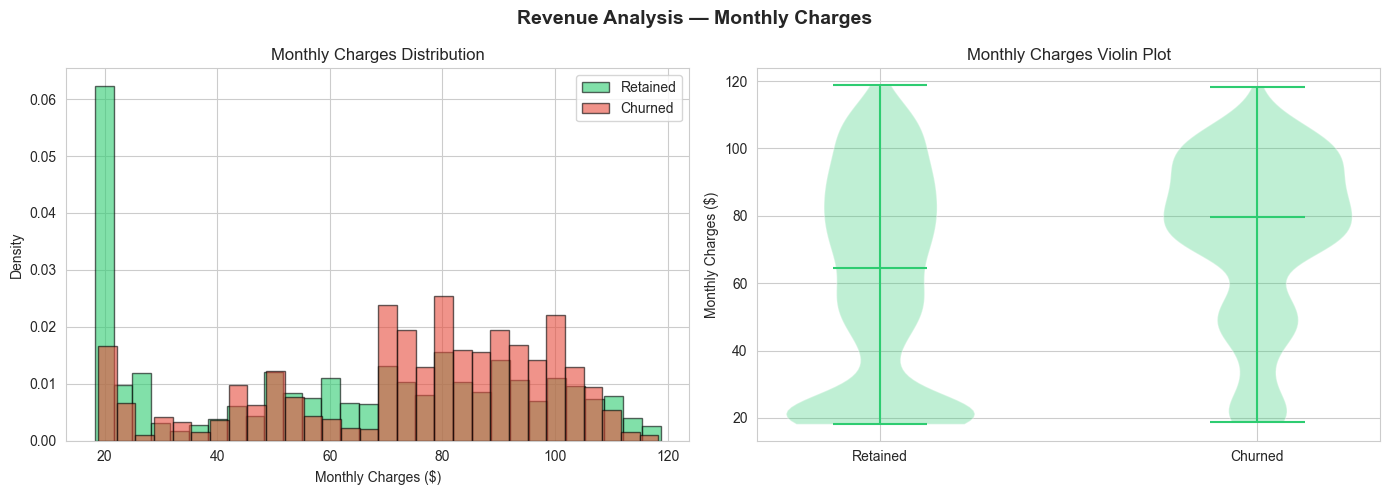

Avg Monthly Charges — Retained: 61.31
Avg Monthly Charges — Churned : 74.44


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
for churn_val, label, color in zip([0, 1], ['Retained', 'Churned'], CHURN_COLORS):
    subset = df[df['Churn'] == churn_val]['MonthlyCharges']
    axes[0].hist(subset, bins=30, density=True, alpha=0.6, label=label,
                 color=color, edgecolor='black')
axes[0].set_title('Monthly Charges Distribution')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Violin plot
data_retained = df[df['Churn']==0]['MonthlyCharges']
data_churned  = df[df['Churn']==1]['MonthlyCharges']
axes[1].violinplot([data_retained, data_churned], positions=[1, 2], showmedians=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_title('Monthly Charges Violin Plot')
axes[1].set_ylabel('Monthly Charges ($)')

plt.suptitle('Revenue Analysis — Monthly Charges', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/06_monthly_charges.png', dpi=150)
plt.show()

print("Avg Monthly Charges — Retained:", df[df['Churn']==0]['MonthlyCharges'].mean().round(2))
print("Avg Monthly Charges — Churned :", df[df['Churn']==1]['MonthlyCharges'].mean().round(2))

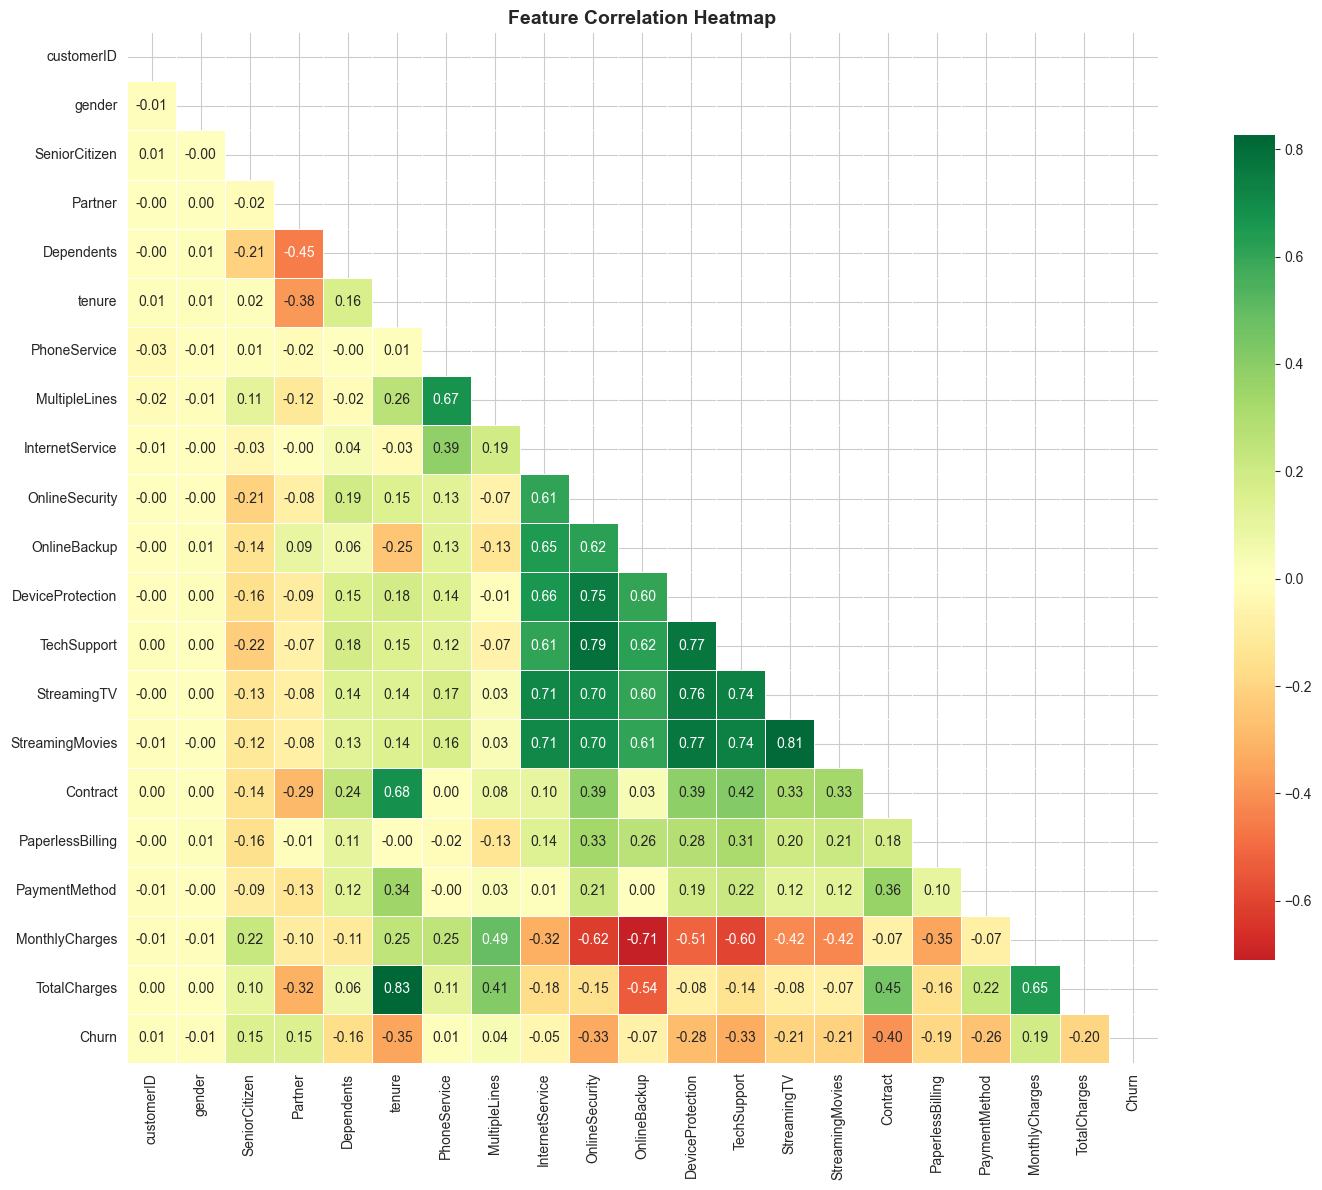

In [9]:
# Encode categoricals temporarily for correlation
df_encoded = df.copy()
cat_cols = df_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

corr = df_encoded.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/07_correlation_heatmap.png', dpi=150)
plt.show()

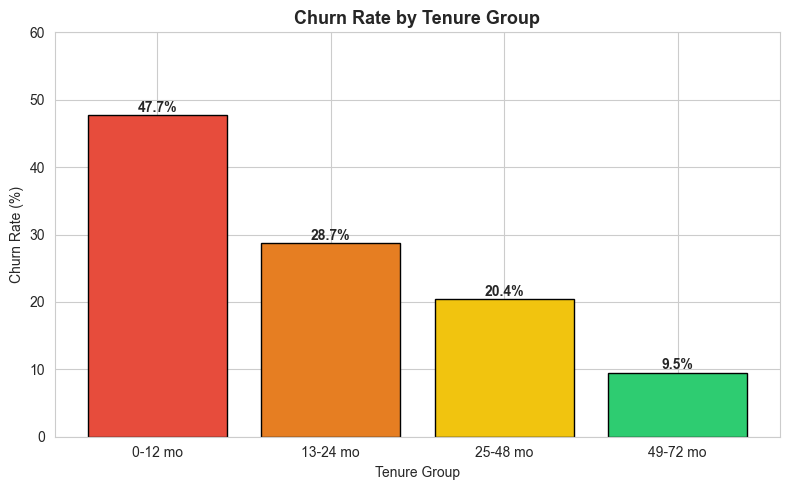

In [10]:
df['TenureGroup'] = pd.cut(df['tenure'],
                            bins=[0, 12, 24, 48, 72],
                            labels=['0-12 mo', '13-24 mo', '25-48 mo', '49-72 mo'])

churn_by_tenure = df.groupby('TenureGroup', observed=True)['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(churn_by_tenure.index.astype(str), churn_by_tenure.values,
               color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'], edgecolor='black')
plt.title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 60)
for bar, val in zip(bars, churn_by_tenure.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/08_churn_by_tenure_group.png', dpi=150)
plt.show()

# Drop temp column
df.drop(columns=['TenureGroup'], inplace=True)

In [11]:
summary = {
    'Churn Rate'              : f"{df['Churn'].mean()*100:.1f}%",
    'Avg Tenure (Churned)'    : f"{df[df['Churn']==1]['tenure'].mean():.1f} months",
    'Avg Tenure (Retained)'   : f"{df[df['Churn']==0]['tenure'].mean():.1f} months",
    'Avg Monthly (Churned)'   : f"${df[df['Churn']==1]['MonthlyCharges'].mean():.2f}",
    'Avg Monthly (Retained)'  : f"${df[df['Churn']==0]['MonthlyCharges'].mean():.2f}",
    'Highest Risk Contract'   : 'Month-to-month (~43%)',
    'Highest Risk Internet'   : 'Fiber optic (~42%)',
    'Highest Risk Payment'    : 'Electronic check',
    'Key Retention Anchors'   : 'OnlineSecurity, TechSupport, Long-term contract',
    'Critical Risk Window'    : 'First 12 months of tenure',
}

for k, v in summary.items():
    print(f"{k:<30}: {v}")

Churn Rate                    : 26.6%
Avg Tenure (Churned)          : 18.0 months
Avg Tenure (Retained)         : 37.7 months
Avg Monthly (Churned)         : $74.44
Avg Monthly (Retained)        : $61.31
Highest Risk Contract         : Month-to-month (~43%)
Highest Risk Internet         : Fiber optic (~42%)
Highest Risk Payment          : Electronic check
Key Retention Anchors         : OnlineSecurity, TechSupport, Long-term contract
Critical Risk Window          : First 12 months of tenure
